# Binary Logistic Regression — Placement Prediction

**Target:** `PlacementStatus` (`Placed` or `NotPlaced`). Run all cells using the Python 3 kernel.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
csv_candidates = [
    Path('placement_predict_50k.csv'),
    Path('../placement_predict_50k.csv'),
    Path('/Users/laliteja/Documents/GitHub/Machine-Learning/Practicals/Gradient Descent in Practice/placement_predict_50k.csv'),
]
csv_path = next((p for p in csv_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('Complete placement_predict_50k.csv was not found.')

placement = pd.read_csv(csv_path)
placement[['PlacementStatus']].value_counts(normalize=True).round(3)

PlacementStatus
Placed             0.699
NotPlaced          0.301
Name: proportion, dtype: float64

In [ ]:
# Features and binary target: Placed = 1, NotPlaced = 0
numeric = ['CGPA', 'Internships', 'Projects', 'AptitudeScore', 'SoftSkillsRating', 'Backlogs']
categorical = ['Stream', 'Gender', 'PlacementTraining']
X = placement[numeric + categorical]
y = (placement['PlacementStatus'] == 'Placed').astype(int)

print('Baseline accuracy (always predict Placed):', round(y.mean(), 4))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

Baseline accuracy (always predict Placed): 0.6987


In [ ]:
preprocessor = ColumnTransformer([
    ('numeric', StandardScaler(), numeric),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical),
])

binary_model = Pipeline([
    ('preprocessing', preprocessor),
    ('logistic_regression', LogisticRegression(max_iter=1000, random_state=42)),
])
binary_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['CGPA','Internships','Projects',...,'Stream','Gender','PlacementTraining']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

Binary logistic regression accuracy: 0.8065
Coefficient shape: (1, 15)

Classification report:

              precision    recall  f1-score   support

   NotPlaced       0.72      0.58      0.65      3013
      Placed       0.83      0.90      0.87      6987

    accuracy                           0.81     10000
   macro avg       0.78      0.74      0.76     10000
weighted avg       0.80      0.81      0.80     10000



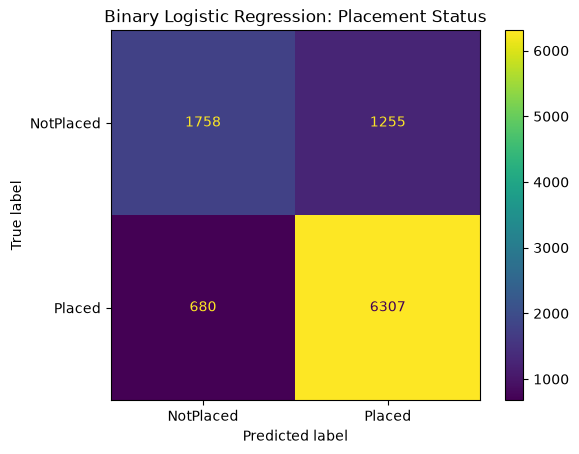

In [ ]:
y_pred = binary_model.predict(X_test)
print('Binary logistic regression accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('Coefficient shape:', binary_model.named_steps['logistic_regression'].coef_.shape)
print('\nClassification report:\n')
print(classification_report(y_test, y_pred, target_names=['NotPlaced', 'Placed']))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['NotPlaced', 'Placed'])
plt.title('Binary Logistic Regression: Placement Status')
plt.show()

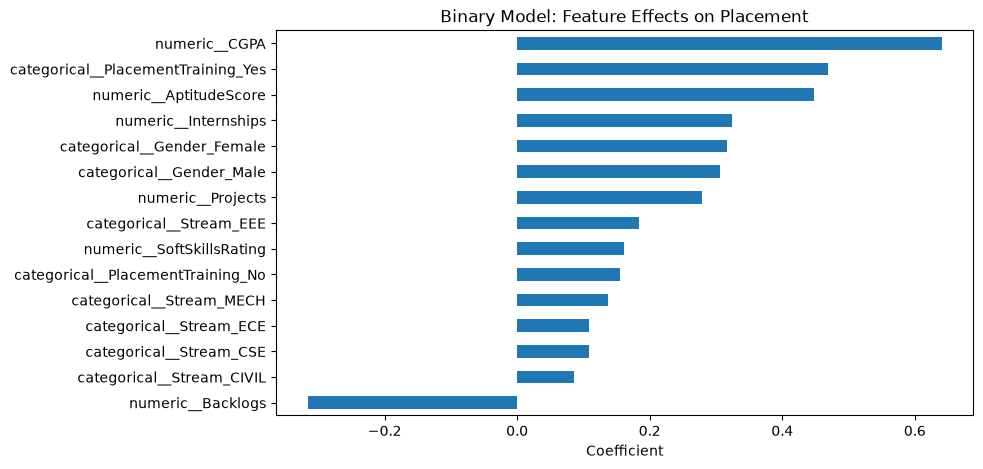

In [ ]:
# A positive coefficient raises placement probability; a negative one lowers it.
feature_names = binary_model.named_steps['preprocessing'].get_feature_names_out()
coefficients = binary_model.named_steps['logistic_regression'].coef_[0]
pd.Series(coefficients, index=feature_names).sort_values().plot.barh(figsize=(9, 5))
plt.xlabel('Coefficient')
plt.title('Binary Model: Feature Effects on Placement')
plt.show()